# Regression Analysis with Stats-Transformer
This notebook demonstrates how to load dataset, configure regression models, and visualize the output using the `stats-transformer` library.

In [1]:
import pandas as pd
from pathlib import Path
from stats_transformer.models.regression.robust_ols import RobustOLSModel
from stats_transformer.visualization.models.regression_viz import RegressionVisualizer

## 1. Data Loading
Load the example macroeconomic dataset.

In [2]:
from stats_transformer.data import load_sample_data

# Load the sample dataset
df = load_sample_data()
df = df.dropna()
df.head()

,country,date,inflation,gdp
0,ABW,1985,4.032258,68.82939
1,ABW,1986,1.073966,68.82134
2,ABW,1987,3.639953,68.89938
3,ABW,1988,3.121032,68.76744
4,ABW,1989,3.989460,68.79722


## 2. Model Fitting
Fit a robust OLS model to the data. We will predict GDP based on inflation.

In [3]:
model = RobustOLSModel(
    target='gdp',
    independent_variables=['inflation'],
    cov_type='HC3'
)
model.fit(df)
print(model.get_summary())

                            OLS Regression Results                            
Dep. Variable:                    gdp   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                 1.410e-10
Date:                Fri, 08 May 2026   Prob (F-statistic):               1.00
Time:                        10:24:20   Log-Likelihood:                -50232.
No. Observations:               11307   AIC:                         1.005e+05
Df Residuals:                   11305   BIC:                         1.005e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         81.5869      0.194    421.586      0.0

## 3. Visualization
Visualize the regression results.

2026-05-08 10:24:22,117 - INFO - Creating coefficient plot from JSON


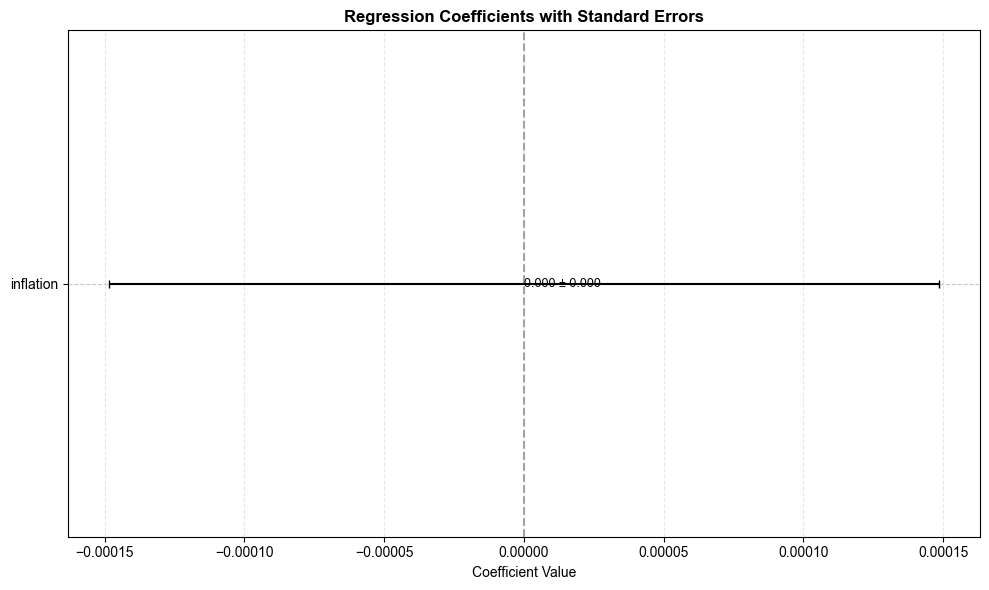

2026-05-08 10:24:22,177 - INFO - Creating model summary plot


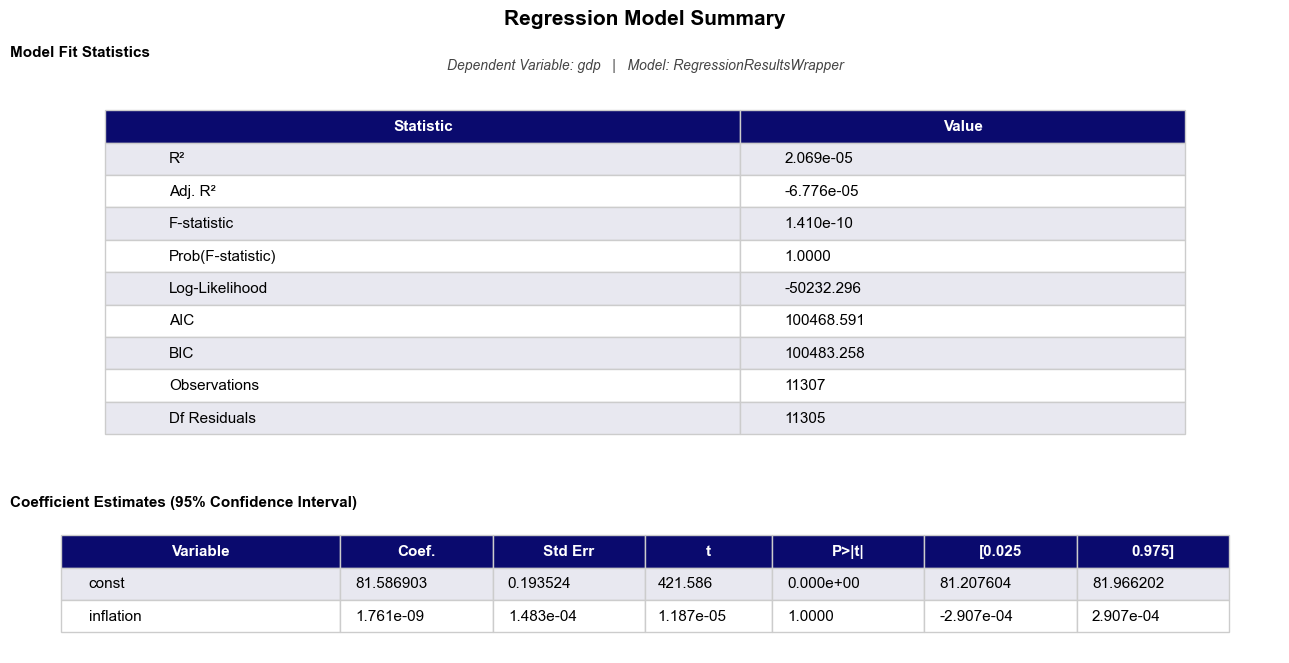

Visualizations available: dict_keys(['coefficient_plot', 'model_summary'])


In [4]:
viz = RegressionVisualizer(output_dir='data/temp/notebook_viz')

# Note: This returns paths to the saved images. In a real notebook, you would display them inline.
metadata = model.get_model_metadata()
paths = viz.visualize_from_json(model_summary=metadata, display_only=True)
print('Visualizations available:', paths.keys())